### Colab Activity 20.1: Implementing Bootstrapping

**Expected Time = 30 minutes**


This activity focuses on the construction of bootstrapped samples using `pandas`.  You will take samples with replacement from the data and build Logistic Regression models on these samples.  This is a starting step towards the random forest using a Decision Tree over a Logistic Regressor.

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)


In [3]:
import matplotlib.pyplot as plt
import numpy as npn
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/sample_data/fetal_health.csv')

In [5]:
X, y = df.drop('fetal_health', axis = 1), df['fetal_health']

In [6]:
X.sample(10, random_state = 42)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
282,133.0,0.002,0.010,0.003,0.002,0.0,0.000,46.0,1.1,0.0,...,69.0,95.0,164.0,5.0,0.0,139.0,135.0,138.0,9.0,0.0
1999,125.0,0.000,0.001,0.009,0.008,0.0,0.000,62.0,1.7,0.0,...,72.0,68.0,140.0,5.0,0.0,130.0,116.0,125.0,29.0,1.0
1709,131.0,0.004,0.003,0.004,0.005,0.0,0.001,60.0,2.1,0.0,...,90.0,78.0,168.0,8.0,0.0,133.0,127.0,132.0,21.0,0.0
988,131.0,0.011,0.000,0.005,0.000,0.0,0.000,29.0,1.3,0.0,...,89.0,82.0,171.0,8.0,0.0,143.0,145.0,145.0,9.0,1.0
2018,125.0,0.000,0.000,0.008,0.007,0.0,0.001,64.0,1.3,0.0,...,77.0,78.0,155.0,4.0,0.0,114.0,111.0,114.0,7.0,0.0
297,148.0,0.000,0.012,0.000,0.000,0.0,0.000,75.0,0.2,84.0,...,7.0,145.0,152.0,1.0,0.0,148.0,148.0,149.0,0.0,0.0
1737,134.0,0.005,0.001,0.007,0.005,0.0,0.000,61.0,1.1,0.0,...,83.0,90.0,173.0,5.0,0.0,142.0,143.0,147.0,17.0,1.0
651,123.0,0.000,0.000,0.000,0.000,0.0,0.000,74.0,0.3,90.0,...,9.0,120.0,129.0,2.0,0.0,123.0,124.0,125.0,0.0,0.0
70,144.0,0.001,0.000,0.005,0.000,0.0,0.000,45.0,0.8,2.0,...,30.0,138.0,168.0,3.0,0.0,162.0,157.0,160.0,5.0,1.0
290,144.0,0.000,0.005,0.000,0.000,0.0,0.000,65.0,0.4,21.0,...,27.0,129.0,156.0,2.0,0.0,150.0,146.0,148.0,3.0,1.0


In [7]:
X.shape

(2126, 21)

[Back to top](#-Index)

### Problem 1

#### Taking Samples with Replacement


Complete the starter code for the `for` loop below as instructed:

- Use the `.sample()` method on the data `X` to take samples with replacement of size 20  Use the iteration index `i` as the `random_state` for each sample and set the argument `replace` equal to `True`.
- Calculate the mean of each `sample` and append it to the list `means`.
- Create a DataFrame named `sample_means` where each row is the observed mean of the sample column in `X`.

In [8]:
means= []
for i in range(100):
  sample = X.sample(20, random_state=i, replace=True)
  sample_mean=sample.mean()
  means.append(sample_mean)

sample_means=pd.DataFrame(means)
sample_means.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,130.85,0.00250,0.00155,0.00420,0.00355,0.0,0.00000,53.75,1.295,10.90,...,81.15,83.50,164.65,5.60,0.45,134.30,130.50,134.85,16.85,0.15
1,133.10,0.00355,0.00120,0.00440,0.00185,0.0,0.00025,41.10,1.395,8.00,...,77.30,84.65,161.95,4.65,0.40,136.40,133.60,137.45,13.45,0.40
2,131.85,0.00225,0.00930,0.00485,0.00295,0.0,0.00040,34.80,1.955,6.85,...,74.05,89.80,163.85,4.05,0.25,133.85,129.55,132.85,26.25,0.20
3,132.60,0.00425,0.00325,0.00455,0.00230,0.0,0.00020,48.10,1.490,5.15,...,75.25,90.95,166.20,4.10,0.40,140.80,135.60,140.20,20.05,0.45
4,134.90,0.00175,0.00335,0.00495,0.00245,0.0,0.00005,40.30,1.310,13.40,...,80.50,83.85,164.35,4.95,0.45,139.05,134.50,138.50,13.00,0.65


[Back to top](#-Index)

### Problem 2

#### Models on samples



Anticipating the bootstrap aggregation, build a logistic regression model on each iterations sample by following the steps below:

- Create `100` bootstrap samples of size `100` from the original dataset `df` using the `sample` method with  `random_state`  equal to `i` and `replace` equal to `True`.
- Split the data into features `X` and target `y`. `X` will contain all column of `df` except the `fetal_health`. `y` will be equal to the `fetal_health` column.
- Instantiate a logistic regression model with `random_state` equal to `42` and fit it to this data `X` and `y`.  
- Store the coefficients from each fitted model in a list `coefs`.


Finally, outside the `for` loop, create a DataFrame `coef_df` from the collected coefficients, with the column names matching those of the feature set `X`.



<table border="1" class="dataframe">  <thead>    <tr style="text-align: right;">      <th></th>      <th>baseline value</th>      <th>accelerations</th>      <th>fetal_movement</th>      <th>uterine_contractions</th>      <th>light_decelerations</th>      <th>severe_decelerations</th>      <th>prolongued_decelerations</th>      <th>abnormal_short_term_variability</th>      <th>mean_value_of_short_term_variability</th>      <th>percentage_of_time_with_abnormal_long_term_variability</th>      <th>mean_value_of_long_term_variability</th>      <th>histogram_width</th>      <th>histogram_min</th>      <th>histogram_max</th>      <th>histogram_number_of_peaks</th>      <th>histogram_number_of_zeroes</th>      <th>histogram_mode</th>      <th>histogram_mean</th>      <th>histogram_median</th>      <th>histogram_variance</th>      <th>histogram_tendency</th>    </tr>  </thead>  <tbody>    <tr>      <th>0</th>      <td>-0.148653</td>      <td>0.000397</td>      <td>-0.000296</td>      <td>0.000575</td>      <td>0.000360</td>      <td>0.000000e+00</td>      <td>-0.000130</td>      <td>-0.326384</td>      <td>0.101630</td>      <td>-0.211499</td>      <td>-0.013581</td>      <td>-0.056798</td>      <td>0.182274</td>      <td>0.125475</td>      <td>-0.021006</td>      <td>-0.016422</td>      <td>-0.033148</td>      <td>0.179841</td>      <td>0.026306</td>      <td>-0.127317</td>      <td>-0.163619</td>    </tr>    <tr>      <th>1</th>      <td>-0.061691</td>      <td>0.000470</td>      <td>0.000546</td>      <td>0.000407</td>      <td>0.000115</td>      <td>-6.669241e-07</td>      <td>-0.000151</td>      <td>-0.353678</td>      <td>0.018719</td>      <td>-0.030565</td>      <td>-0.063293</td>      <td>0.105792</td>      <td>0.058392</td>      <td>0.164184</td>      <td>-0.175497</td>      <td>-0.044569</td>      <td>-0.253011</td>      <td>0.240469</td>      <td>0.017689</td>      <td>-0.159757</td>      <td>-0.078947</td>    </tr>    <tr>      <th>2</th>      <td>-0.075481</td>      <td>0.000434</td>      <td>-0.000229</td>      <td>0.000297</td>      <td>0.000023</td>      <td>0.000000e+00</td>      <td>-0.000075</td>      <td>-0.323813</td>      <td>0.092076</td>      <td>-0.143590</td>      <td>-0.075241</td>      <td>0.005551</td>      <td>0.065393</td>      <td>0.070944</td>      <td>-0.032991</td>      <td>-0.144008</td>      <td>0.071054</td>      <td>-0.055390</td>      <td>0.134176</td>      <td>-0.051194</td>      <td>-0.000221</td>    </tr>    <tr>      <th>3</th>      <td>-0.130622</td>      <td>0.001060</td>      <td>-0.003256</td>      <td>0.000483</td>      <td>0.000370</td>      <td>0.000000e+00</td>      <td>-0.000067</td>      <td>-0.274047</td>      <td>0.164185</td>      <td>-0.206988</td>      <td>0.014520</td>      <td>0.078620</td>      <td>-0.122271</td>      <td>-0.043652</td>      <td>-0.082847</td>      <td>0.120812</td>      <td>0.180340</td>      <td>-0.121190</td>      <td>0.433346</td>      <td>-0.212897</td>      <td>0.001096</td>    </tr>    <tr>      <th>4</th>      <td>-0.073390</td>      <td>0.000639</td>      <td>-0.000244</td>      <td>0.002119</td>      <td>0.000060</td>      <td>0.000000e+00</td>      <td>-0.000014</td>      <td>-0.508164</td>      <td>0.152837</td>      <td>-0.303871</td>      <td>0.017631</td>      <td>0.005860</td>      <td>0.065243</td>      <td>0.071102</td>      <td>-0.037210</td>      <td>-0.435003</td>      <td>0.116637</td>      <td>0.077635</td>      <td>0.117680</td>      <td>-0.090842</td>      <td>-0.008462</td>    </tr>  </tbody></table>


In [9]:
print(f"Unique values in 'fetal_health' (y): {y.unique()}")
print(f"Number of unique values in 'fetal_health' (y): {len(y.unique())}")

Unique values in 'fetal_health' (y): [2. 1. 3.]
Number of unique values in 'fetal_health' (y): 3


The output of `len(lr.coef_)` being `3` is because the `fetal_health` target variable has 3 unique classes (1, 2, and 3). In `sklearn`'s `LogisticRegression` for multi-class classification, `lr.coef_` will have a row of coefficients for each class.

In [15]:
coefs = []
for i in range(100):
    sample_df = df.sample(100, random_state=i, replace=True)
    X = sample_df.drop(columns = ['fetal_health'])
    y = sample_df['fetal_health']
    lr = LogisticRegression(random_state=42)
    lr.fit(X,y)
    # Prepare the data frame coefs from lr.coef_ considering there are 3 classes in this multinomial logistic regression
    #problem hence each lr.coef_ has size of 3
    #for j in range(len(lr.coef_)):
    coefs.append(lr.coef_[0])

coef_df = pd.DataFrame(coefs)

### ANSWER CHECK
print(f"shape of coef_df = {coef_df.shape}")
coef_df.head()

shape of coef_df = (100, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,-0.129861,0.000347,-0.000262,0.000503,0.000314,0.000000e+00,-0.000114,-0.286096,0.088550,-0.183032,...,-0.052520,0.155115,0.102595,-0.015298,-0.014912,-0.019976,0.159756,0.027755,-0.112598,-0.142085
1,-0.061691,0.000470,0.000546,0.000407,0.000115,-6.669265e-07,-0.000151,-0.353680,0.018719,-0.030565,...,0.105792,0.058392,0.164184,-0.175497,-0.044569,-0.253012,0.240470,0.017689,-0.159758,-0.078947
2,-0.075482,0.000434,-0.000229,0.000297,0.000023,0.000000e+00,-0.000075,-0.323814,0.092076,-0.143591,...,0.005551,0.065393,0.070944,-0.032991,-0.144009,0.071054,-0.055390,0.134176,-0.051195,-0.000221
3,-0.130623,0.001060,-0.003257,0.000483,0.000370,0.000000e+00,-0.000067,-0.274053,0.164191,-0.206994,...,0.078622,-0.122275,-0.043653,-0.082851,0.120816,0.180345,-0.121197,0.433358,-0.212903,0.001095
4,-0.073272,0.000687,-0.000278,0.002318,0.000062,0.000000e+00,-0.000015,-0.525573,0.168001,-0.316386,...,0.003202,0.067596,0.070798,-0.027410,-0.467669,0.120154,0.077218,0.127251,-0.092318,-0.008525


In [18]:
type(coef_df)

pandas.core.frame.DataFrame

[Back to top](#-Index)

### Problem 3

#### Correlation of Models



The multiple models are all built on the same features for the data.  Do you think these models are highly correlated?  Answer "yes" or "no" as a string to `ans3` below.  


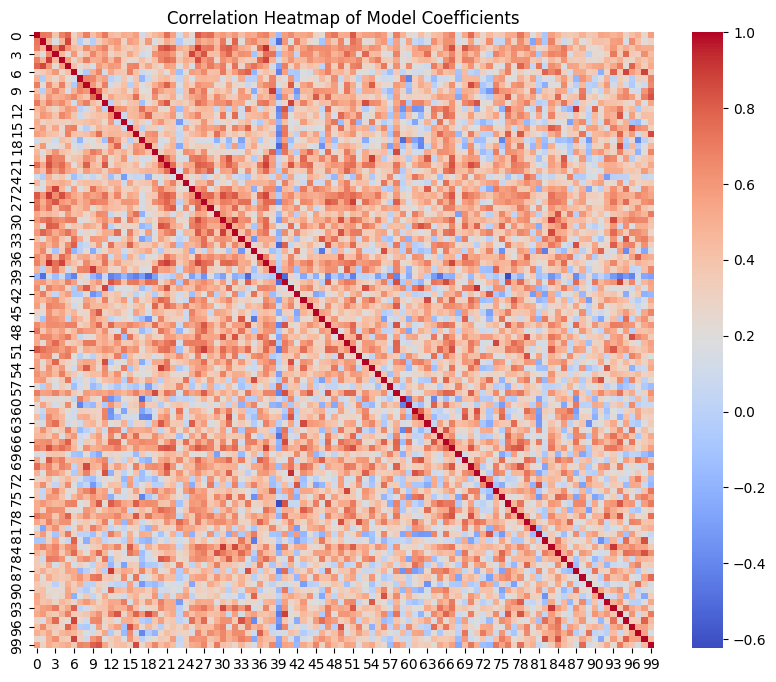

Are the models highly correlated? yes


In [22]:
ans3 = ''
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import pearsonr
import numpy as np

# Use the correlation functions in scipy.stats (like scipy.stats.pearsonr)
# to compute exact correlation coefficients between model prediction arrays.
# To correlate models (rows of coef_df), we need to transpose the DataFrame.
corr_matrix = coef_df.T.corr()
# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f") # Set annot to False for readability with many models

plt.title('Correlation Heatmap of Model Coefficients')
plt.show()

# Based on the heatmap (which should show high correlation between models),
# set ans3 to 'yes' or 'no'.
# Bootstrapped models are generally highly correlated.
ans3 = 'yes'

### ANSWER CHECK
print(f"Are the models highly correlated? {ans3}")

(100, 21)

In [ ]:
from scipy.stats import pearsonr
import numpy as np

x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]
z = [3, 6, 9, 12, 130]
# Perfect positive correlation (r=1.0)
corr, p_value = pearsonr(z, y)
print(f"Correlation: {corr}, P-value: {p_value}")
